In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd drive/MyDrive/

/content/drive/MyDrive


In [4]:
df = pd.read_csv('Smart-Warehouse-Delay/data/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


#
### **📦 12. 상품 특성**
* heavy_item_ratio → 무거운 상품 비율
* cold_chain_ratio → 냉장/냉동 상품 비율
* avg_package_weight_kg → 평균 패키지 무게
* sku_concentration → SKU 집중도
* return_order_ratio → 반품 비율

In [5]:
product = df[["heavy_item_ratio","cold_chain_ratio","avg_package_weight_kg",
        "sku_concentration","return_order_ratio"]]
product

,heavy_item_ratio,cold_chain_ratio,avg_package_weight_kg,sku_concentration,return_order_ratio
0,0.1765,0.0392,6.72,0.3063,0.0193
1,NaN,0.0149,10.95,NaN,0.0302
2,0.2283,0.0217,10.90,0.3063,0.0195
3,NaN,0.0390,13.13,0.3063,0.0564
4,0.3333,NaN,13.66,0.3063,0.0366
...,...,...,...,...,...
249995,0.1795,NaN,7.93,NaN,0.0572
249996,0.2319,0.0290,8.70,0.2226,0.0567
249997,0.3934,0.0820,9.95,0.2226,0.0731
249998,0.1667,0.0185,6.46,0.2226,0.0918


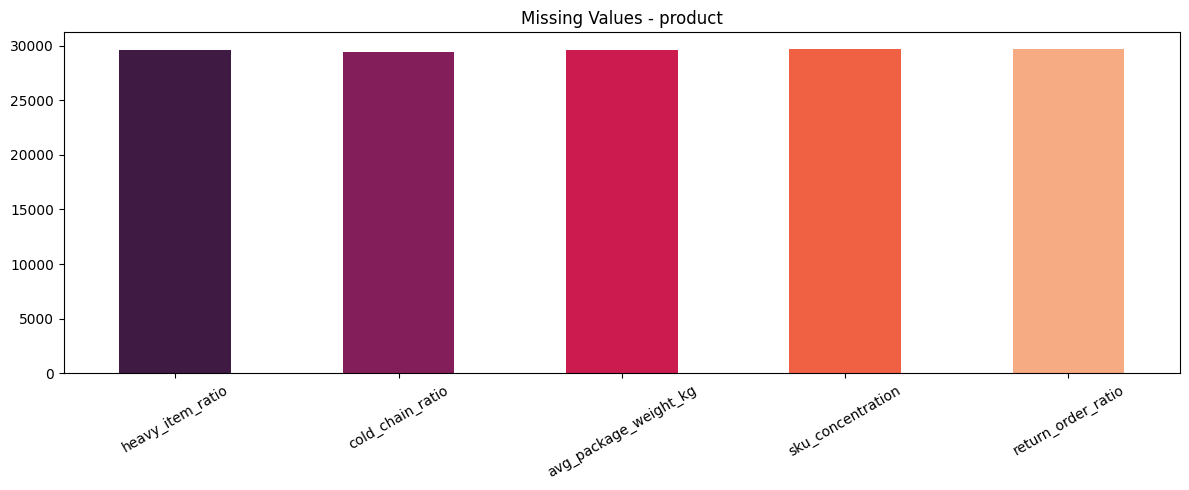

In [6]:
missing = product.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - product')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**

In [7]:
corr = product.corr()
corr

,heavy_item_ratio,cold_chain_ratio,avg_package_weight_kg,sku_concentration,return_order_ratio
heavy_item_ratio,1.000000,0.284784,0.397791,0.509192,0.008844
cold_chain_ratio,0.284784,1.000000,0.119340,0.439711,0.013105
avg_package_weight_kg,0.397791,0.119340,1.000000,0.208406,-0.001759
sku_concentration,0.509192,0.439711,0.208406,1.000000,0.017634
return_order_ratio,0.008844,0.013105,-0.001759,0.017634,1.000000


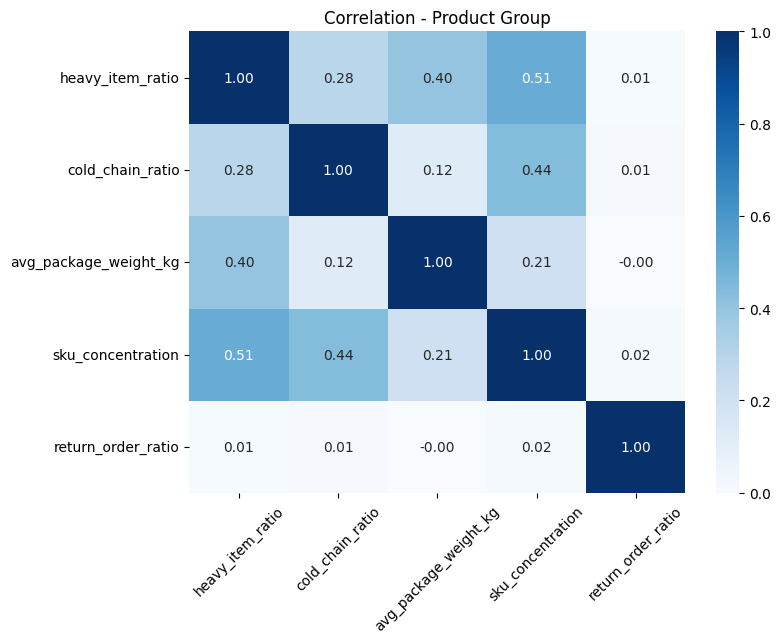

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Product Group')
plt.xticks(rotation=45)
plt.show()